# 1. 딥러닝

- 이번 Part 목표
1. 딥러닝, 전통 머신러닝의 관계 구분
2. 딥러닝에서 말하는 특징 학습이 무엇인지 설명
3. 입력 -> 예측 -> 손실 -> 가중치 수정 의 학습 흐름 이해
4. 하나의 가중치가 학습되는 과정을 숫자로 계산

---

# 2. 딥러닝 직관적 이해

### 2.1 딥러닝은 머신러닝의 한 종류이다.

관계를 간단히 표현하면

인공지능 ⊃ 머신러닝 ⊃ 딥러닝

- 머신러닝: 데이터를 이용해 규칙을 학습하는 방법
- 딥러닝: 여러 층으로 구성된 신경망을 이용하는 머신런이 방법

따라서 머신러닝과 딥러닝이 완전 별개의 분야는 아니다.

---

### 2.2 전통 머신러닝과 딥러닝의 차이

| 구분      | 전통 머신러닝                 | 딥러닝                        |
| ------- | ----------------------- | -------------------------- |
| 대표 모델   | KNN, SVM, Random Forest | MLP, CNN, RNN, Transformer |
| 입력      | 사람이 정리한 feature가 주로 사용됨 | 원본에 가까운 고차원 데이터도 사용 가능     |
| 특징 추출   | 사람의 전처리·설계 비중이 큼        | 신경망이 학습 과정에서 표현을 함께 학습     |
| 데이터 요구량 | 비교적 적은 데이터에서도 동작 가능     | 일반적으로 더 많은 데이터가 필요         |
| 연산량     | 상대적으로 작음                | 상대적으로 큼                    |
| 강점 데이터  | 표 형식 데이터, 소규모 데이터       | 이미지, 음성, 텍스트 등             |
| 엣지 배포   | 비교적 쉬움                  | 경량화와 가속이 중요                |

딥러닝이 언제나 더 좋은 것은 아니다.

EX:
> AP 별 RSSI 평균, 분산 
>
> 이미 잘 정리된 표 형식 데이터가 적게 있는 경우
>
> -> Random Forest, SVM 구조가 더 적잘할 수 있음

> 이미지의 픽셀, RSSI 시간 변화
>
> -> 딥러닝이 유용

---

### 2.3 특징 학습

EX: 고양이 이미지 분류

전통적인 접근: 사람이 아래와 같은 특징을 만들어 모델에 전달할 수 있음

- 색상 분포
- 윤곽선 개수
- 귀처럼 뾰족한 부분의 모양
- 특정 방향의 선분


딥러닝 CNN: 이미지 픽셀이나, RSSI 시간 변화처럼 입력 구조가 복잡하면 딥러닝이 유용할 가능성이 커진다.

- 앞부분 층: 선, 모서리처럼 단순한 패턴
- 중간 층: 질감이나 부분 구조
- 뒤쪽 층: 분류에 유용한 복합적인 형태

이를 **특징 학습** 또는 **표현 학습** 이라고 한다.

다만, 실제 신경망의 각 층이 만드시 사람이 이해할 수 있는 "귀", "눈"을 정확히 담당하는 것은 아니다.

신경망은 정답을 잘 예측하는 데 유용한 수치적 패턴을 학습한다.

---

# 3. 신경망 학습의 기본 수식

딥러닝 학습은 크게 네 단계로 정리 가능하다.

### 3.1 예측
입력 x를 모델에 넣어 예측값을 만든다.

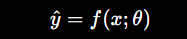

- x: 입력 데이터
- y: 실제 정답
- ^y: 모델의 예측
- f: 모델
- θ: 모델이 학습할 파라미터

여기서 파이미터는 가중치 w, 편향 b 같은 값이다.

---

### 3.2 손실 계산

예측과 정답의 차이를 손실함수로 계산한다.

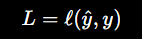

손실 L이 작을수록 현재 예측이 정답에 가깝다는 의미이다.

---

### 3.3 기울기 계산

손실을 줄이려면 가중치를 어느 방향으로 바꿔야 하는지 계산한다.

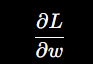

이 값을 가중치에 대한 손실의 기울기라고 한다.

---

### 3.4 가중치 수정

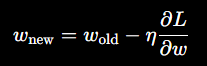

- η: Learning rate
- 기울기가 양수 -> 거중치 감소시킴
- 기울기가 음수 -> 가중치 증가시킴

---

# 실제 숫자로 계산해보기

편향이 없는 뉴런 하나를 가정하면

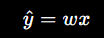

가정
- x = 2
- y = 3
- w = 0.5

### ① 예측
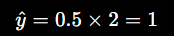

### ② 손실
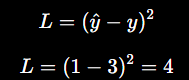

평균제곱오차의 간단한 형태 사용

### ③ 가중치의 기울기
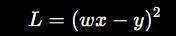

연쇄법칙으로 미분하면 다음과 같다.

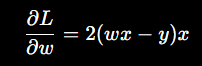

숫자 대입시

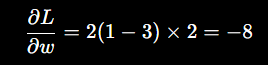

### ④ 가중치 수정

learning rate 를 0.1로 설정

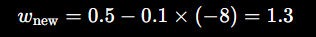

### ⑤ 새로운 예측과 손실

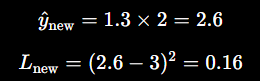

가중치가 0.5 -> 1.3 으로 바뀌면서 손실이 4 -> 1.6 으로 감소함

이것이 신경망 학습의 가장 작은 형태이다.

---

# 4. 실행 가능한 최소 PyTorch 코드

### 1. 실행 환경 확인

In [1]:
import torch
from torch import nn

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Pytorch version:", torch.__version__)
print("Device:", device)

Pytorch version: 2.13.0+cu129
Device: cuda


---

### 셀 2: 가중치 한 번 학습시키기

In [ ]:
# 입력과 정답

x = torch.tensor([[2.0]], device=device)
y = torch.tensor([[3.0]], device=device)

